In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
house_data = pd.DataFrame({
    "price": [10, 20, 30, 40, 50, 60, 70, 10]
})

In [13]:
house_data

,price
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,10


In [14]:
house_data.describe()

,price
count,8.000000
mean,36.250000
std,22.638463
min,10.000000
25%,17.500000
50%,35.000000
75%,52.500000
max,70.000000


# Central Tendency

## mean

In [15]:
mean = house_data["price"].mean()
print(mean)

36.25


## median

In [35]:
median = house_data["price"].median()
print(median)

35.0


## mode

In [36]:
mode = house_data["price"].mode()
print(mode)

0    10
Name: price, dtype: int64


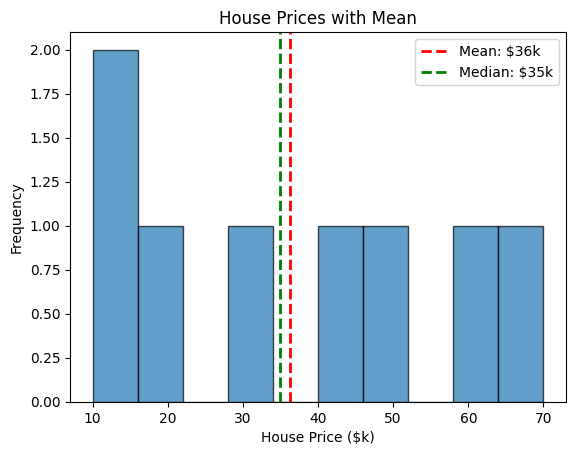

In [39]:
plt.hist(house_data["price"], bins=10, alpha=0.7, edgecolor="black")
plt.axvline(mean, color='red', linestyle="--", linewidth=2, label=f"Mean: ${mean:.0f}k")
plt.axvline(median, color="green", linestyle="--", linewidth=2, label=f"Median: ${median:.0f}k")
plt.xlabel("House Price ($k)")
plt.ylabel("Frequency")
plt.title("House Prices with Mean")
plt.legend()

plt.show()

# Variance and Standard Deviation

In [48]:
var = np.var(house_data["price"])
std = np.std(house_data["price"])

print(f"Variance: {var}")
print(f"Standard Deviation: {std}")
print(f"Mean: {mean}")

lowest_range = mean-std
highest_range = mean+std
print(house_data)
print(f"{lowest_range} - {highest_range}")

Variance: 448.4375
Standard Deviation: 21.176342932621772
Mean: 36.25
   price
0     10
1     20
2     30
3     40
4     50
5     60
6     70
7     10
15.073657067378228 - 57.42634293262177


# Percentiles and Quartiles

In [51]:
perc = np.percentile(house_data["price"], 30)
print(perc)

21.0


In [59]:
Q0 = np.percentile(house_data["price"], 0)
Q1 = np.percentile(house_data["price"], 25)
Q2 = np.percentile(house_data["price"], 50)
Q3 = np.percentile(house_data["price"], 75)
Q4 = np.percentile(house_data["price"], 100)

print(f"Q0-{Q0}\nQ1-{Q1}\nQ2-{Q2}\nQ3-{Q3}\nQ4-{Q4}")

Q0-10.0
Q1-17.5
Q2-35.0
Q3-52.5
Q4-70.0


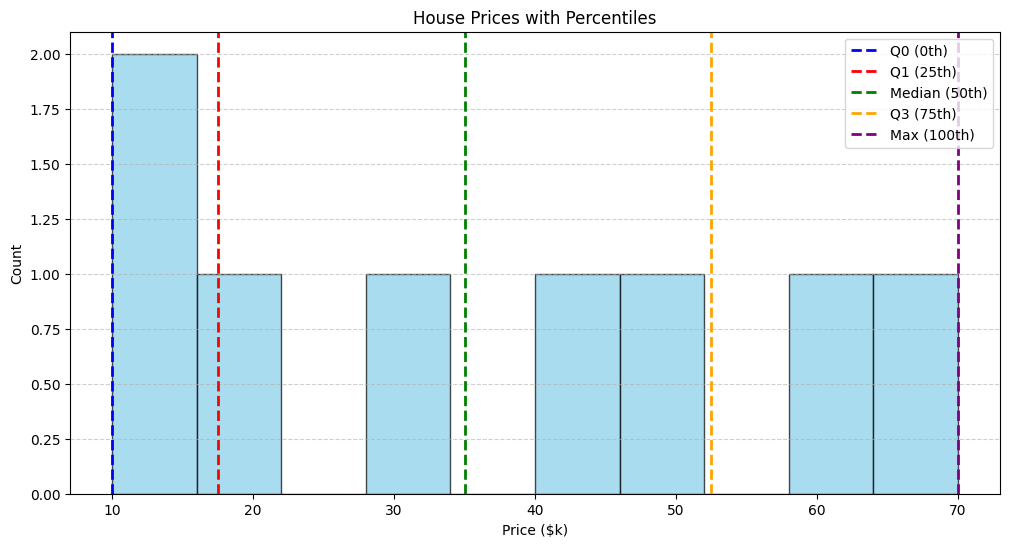

In [71]:
plt.figure(figsize=(12, 6))

plt.hist(house_data["price"], bins=10, color="skyblue", edgecolor="black", alpha=0.7)

plt.axvline(Q0, color="blue", linestyle="--", linewidth=2, label="Q0 (0th)")
plt.axvline(Q1, color="red", linestyle="--", linewidth=2, label="Q1 (25th)")
plt.axvline(Q2, color="green", linestyle="--", linewidth=2, label="Median (50th)")
plt.axvline(Q3, color="orange", linestyle="--", linewidth=2, label="Q3 (75th)")
plt.axvline(Q4, color="purple", linestyle="--", linewidth=2, label="Max (100th)")

plt.title("House Prices with Percentiles")
plt.xlabel("Price ($k)")
plt.ylabel("Count")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

# Measures of Spread

## Range

In [72]:
## Range = max - min
range = house_data["price"].max() - house_data["price"].min()
print(f"Range - {range}")

Range - 60


## IQR

In [73]:
# IQR = Q3 (75%) - Q1 (25%)
IQR = Q3 - Q1
print(IQR)

35.0


# Outlier detection

In [75]:
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

print(f"{lower} -- {upper}")

# values outside this range will be considered as outlier 

-35.0 -- 105.0


## Z-Score

z = (x - μ) / σ

x = যে ডেটা পয়েন্টের Z-স্কোর বের করবো

μ (mu) = পুরো ডেটাসেটের গড় (Mean)

σ (sigma) = পুরো ডেটাসেটের স্ট্যান্ডার্ড ডিভিয়েশন

Outlier detect (Z-score threshold)

সাধারণত: -3 < z < +3 → normal

z > 3 or z < -3 → extreme / outlier

In [76]:
mean_price = house_data["price"].mean()
std_price = house_data["price"].std(ddof=0)     # if 0 is passed, it will calculate population standard deviation. otherwise, it will calculate sample standard deviation
house_data["z-score"] = (house_data["price"] - mean_price)/std_price
house_data

,price,z-score
0,10,-1.239591
1,20,-0.767366
2,30,-0.295141
3,40,0.177084
4,50,0.649309
5,60,1.121535
6,70,1.593760
7,10,-1.239591


## Modified Z-Score

![modified Z-Score](mzi.png)


Interpretation

Usually, |Modified Z| > 3.5 → suspected outlier

In [77]:
def modified_z_score(x):
    x_median = x.median()
    mad = abs(x-x_median).median()
    mzs = (0.6745 * (x - x_median))/mad
    return mzs

In [78]:
house_data["modified_z_score"] = modified_z_score(house_data["price"])
house_data

,price,z-score,modified_z_score
0,10,-1.239591,-0.843125
1,20,-0.767366,-0.505875
2,30,-0.295141,-0.168625
3,40,0.177084,0.168625
4,50,0.649309,0.505875
5,60,1.121535,0.843125
6,70,1.593760,1.180375
7,10,-1.239591,-0.843125


# Distribution Shapes - Skewness & Visualization

House  -0.36774622946790675
Math  -2.864676715870261


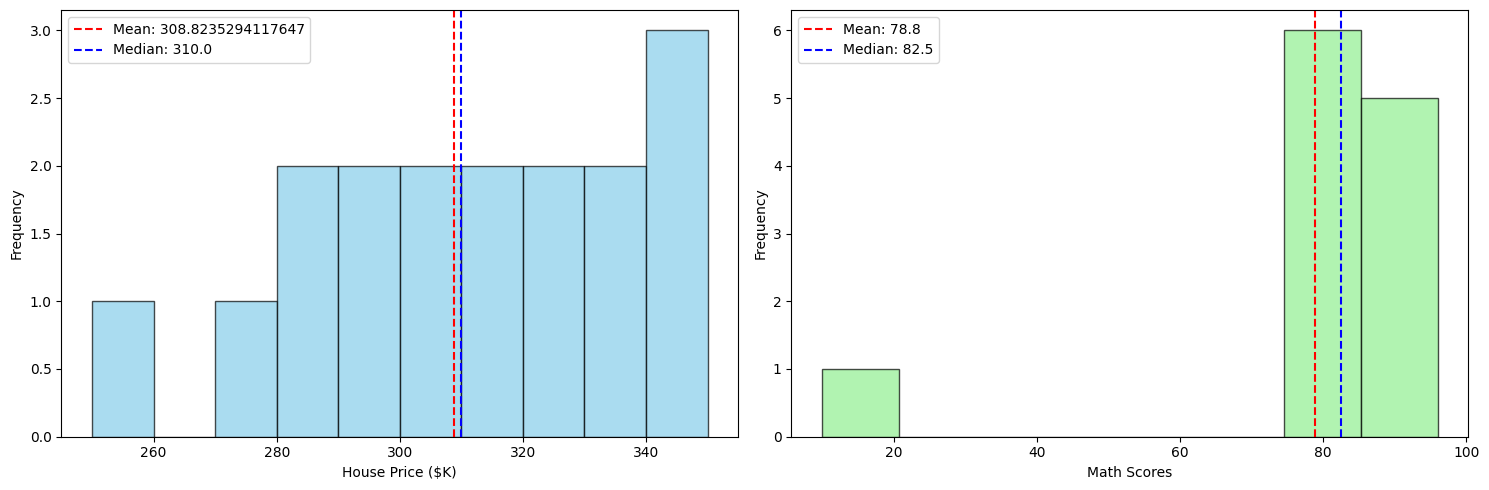

In [79]:
house_data = pd.DataFrame({
    'price': [250, 275, 280, 285, 290, 295, 300, 305, 310, 315,
              320, 325, 330, 335, 340, 345, 350]
})

student_data = pd.DataFrame({
    'math_scores': [10, 90, 96, 75, 80, 92, 88, 95, 76, 81, 79, 84],
})


house_skew = house_data['price'].skew()
math_skew = student_data['math_scores'].skew()

print("House " ,house_skew)
print("Math ", math_skew)

house_mean = house_data['price'].mean()
house_median = house_data['price'].median()

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.hist(house_data['price'], bins=10, alpha=0.7, edgecolor='black', color='skyblue')
plt.axvline(house_mean, color='red', linestyle='--', label=f'Mean: {house_mean}')
plt.axvline(house_median, color='blue', linestyle='--', label=f'Median: {house_median}')
plt.xlabel('House Price ($K)')
plt.ylabel('Frequency')
plt.legend()

math_mean = student_data['math_scores'].mean()
math_median = student_data['math_scores'].median()

plt.subplot(1, 2, 2)
plt.hist(student_data['math_scores'], bins=8, alpha=0.7, edgecolor='black', color='lightgreen')
plt.axvline(math_mean, color='red', linestyle='--', label=f'Mean: {math_mean:.1f}')
plt.axvline(math_median, color='blue', linestyle='--', label=f'Median: {math_median}')
plt.xlabel('Math Scores')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()


Value = 0 → perfect symmetric

Positive → right-skewed

Negative → left-skewed

Machine learning / EDA:

|skew| < 0.5 → normally considered “acceptable”

0.5 < |skew| < 1 → moderate skew, may consider transformation

|skew| > 1 → highly skewed, consider log/sqrt transformation